<a href="https://colab.research.google.com/github/SLIIT-Y4-S2-DL-ORG/Deep-Learning-Assignment/blob/main/MLP/MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: []


In [2]:
import random
import os

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

os.environ["PYTHONHASHSEED"] = str(SEED)

In [3]:
!wget -q \
'https://archive.ics.uci.edu/static/public/240/human%2Bactivity%2Brecognition%2Busing%2Bsmartphones.zip' \
-O har.zip

!unzip -q har.zip

print("Dataset downloaded and extracted.")

Dataset downloaded and extracted.


In [4]:
!ls

 har.zip   sample_data	'UCI HAR Dataset.names'  'UCI HAR Dataset.zip'


In [8]:
!unzip -q "/content/UCI HAR Dataset.zip" -d /content/

In [10]:
!ls "/content/UCI HAR Dataset"
!ls "/content/UCI HAR Dataset/train/Inertial Signals" | head

activity_labels.txt  features_info.txt	features.txt  README.txt  test	train
body_acc_x_train.txt
body_acc_y_train.txt
body_acc_z_train.txt
body_gyro_x_train.txt
body_gyro_y_train.txt
body_gyro_z_train.txt
total_acc_x_train.txt
total_acc_y_train.txt
total_acc_z_train.txt


In [11]:
import numpy as np
import os

BASE_PATH = "/content/UCI HAR Dataset"

SIGNALS = [
    "body_acc_x",
    "body_acc_y",
    "body_acc_z",
    "body_gyro_x",
    "body_gyro_y",
    "body_gyro_z",
    "total_acc_x",
    "total_acc_y",
    "total_acc_z"
]

def load_signals(split):
    signal_data = []

    for signal in SIGNALS:
        filename = os.path.join(
            BASE_PATH,
            split,
            "Inertial Signals",
            f"{signal}_{split}.txt"
        )

        signal_data.append(np.loadtxt(filename))

    # Original individual signal shape:
    # (samples, 128)

    # Combine nine channels:
    # (samples, 128, 9)
    return np.transpose(np.array(signal_data), (1, 2, 0))


X_train_full = load_signals("train")
X_test = load_signals("test")

print("Training shape:", X_train_full.shape)
print("Test shape:", X_test.shape)

Training shape: (7352, 128, 9)
Test shape: (2947, 128, 9)


In [12]:
y_train_full = np.loadtxt(
    os.path.join(BASE_PATH, "train", "y_train.txt"),
    dtype=int
)

y_test = np.loadtxt(
    os.path.join(BASE_PATH, "test", "y_test.txt"),
    dtype=int
)

print("Original labels:", np.unique(y_train_full))

Original labels: [1 2 3 4 5 6]


In [13]:
activity_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

In [14]:
y_train_full = y_train_full - 1
y_test = y_test - 1

print(np.unique(y_train_full))

[0 1 2 3 4 5]


In [15]:
train_counts = pd.Series(y_train_full).value_counts().sort_index()
test_counts = pd.Series(y_test).value_counts().sort_index()

distribution = pd.DataFrame({
    "Activity": activity_names,
    "Train": train_counts.values,
    "Test": test_counts.values
})

distribution

,Activity,Train,Test
0,WALKING,1226,496
1,WALKING_UPSTAIRS,1073,471
2,WALKING_DOWNSTAIRS,986,420
3,SITTING,1286,491
4,STANDING,1374,532
5,LAYING,1407,537


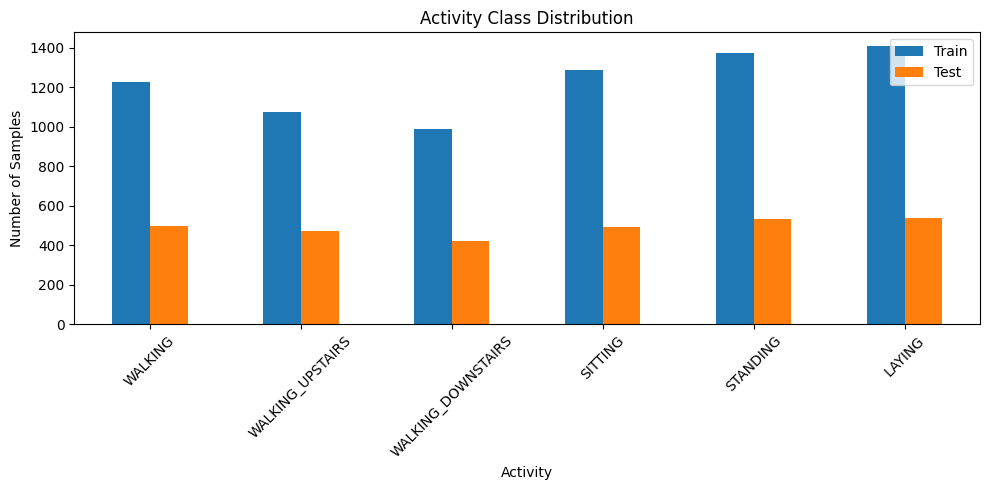

In [16]:
distribution.set_index("Activity")[["Train", "Test"]].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Activity Class Distribution")
plt.xlabel("Activity")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
subject_train = np.loadtxt(
    os.path.join(BASE_PATH, "train", "subject_train.txt"),
    dtype=int
)

subject_test = np.loadtxt(
    os.path.join(BASE_PATH, "test", "subject_test.txt"),
    dtype=int
)

print("Training subjects:", np.unique(subject_train))
print("Testing subjects:", np.unique(subject_test))

print("Number of train subjects:", len(np.unique(subject_train)))
print("Number of test subjects:", len(np.unique(subject_test)))

Training subjects: [ 1  3  5  6  7  8 11 14 15 16 17 19 21 22 23 25 26 27 28 29 30]
Testing subjects: [ 2  4  9 10 12 13 18 20 24]
Number of train subjects: 21
Number of test subjects: 9


In [18]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=SEED
)

train_idx, val_idx = next(
    gss.split(
        X_train_full,
        y_train_full,
        groups=subject_train
    )
)

X_train = X_train_full[train_idx]
y_train = y_train_full[train_idx]

X_val = X_train_full[val_idx]
y_val = y_train_full[val_idx]

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print(
    "Train subjects:",
    np.unique(subject_train[train_idx])
)

print(
    "Validation subjects:",
    np.unique(subject_train[val_idx])
)

Train: (5551, 128, 9)
Validation: (1801, 128, 9)
Test: (2947, 128, 9)
Train subjects: [ 5  6  7  8 11 14 16 17 19 21 22 23 26 28 29 30]
Validation subjects: [ 1  3 15 25 27]


In [19]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print("Train:", X_train_flat.shape)
print("Validation:", X_val_flat.shape)
print("Test:", X_test_flat.shape)

Train: (5551, 1152)
Validation: (1801, 1152)
Test: (2947, 1152)


In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_flat)

X_val_scaled = scaler.transform(X_val_flat)

X_test_scaled = scaler.transform(X_test_flat)

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    BatchNormalization
)

model = Sequential([
    Input(shape=(1152,)),

    Dense(256, activation="relu"),
    BatchNormalization(),
    Dropout(0.30),

    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.30),

    Dense(64, activation="relu"),
    Dropout(0.20),

    Dense(6, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 338,246 (1.29 MB)

 Trainable params: 337,478 (1.29 MB)

 Non-trainable params: 768 (3.00 KB)

In [22]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [23]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

In [24]:
import time

start_time = time.time()

history = model.fit(
    X_train_scaled,
    y_train,

    validation_data=(
        X_val_scaled,
        y_val
    ),

    epochs=100,
    batch_size=64,

    callbacks=[
        early_stopping,
        reduce_lr
    ],

    verbose=1
)

training_time = time.time() - start_time

print(
    f"Training time: {training_time:.2f} seconds"
)

Epoch 1/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.6898 - loss: 0.8055 - val_accuracy: 0.8851 - val_loss: 0.4180 - learning_rate: 0.0010
Epoch 2/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8370 - loss: 0.4016 - val_accuracy: 0.9561 - val_loss: 0.1773 - learning_rate: 0.0010
Epoch 3/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8771 - loss: 0.3079 - val_accuracy: 0.9639 - val_loss: 0.1394 - learning_rate: 0.0010
Epoch 4/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9049 - loss: 0.2444 - val_accuracy: 0.9650 - val_loss: 0.1334 - learning_rate: 0.0010
Epoch 5/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9072 - loss: 0.2236 - val_accuracy: 0.9545 - val_loss: 0.1520 - learning_rate: 0.0010
Epoch 6/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9191 - loss: 0.1906 - val_accuracy: 0.9622 - val_loss: 0.1634 - learning_rate: 0.0010
Epoch 7/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9269 - loss: 0.1711 - val_a

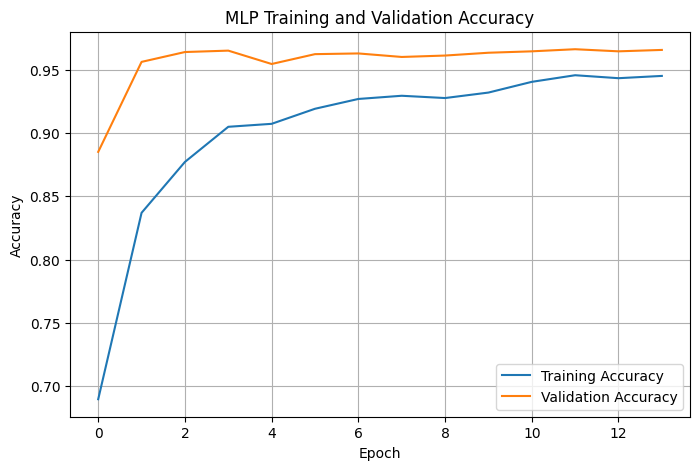

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MLP Training and Validation Accuracy")
plt.legend()
plt.grid()

plt.show()

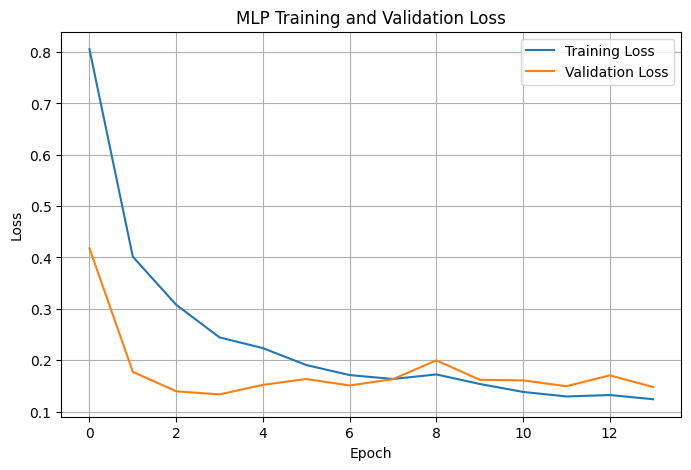

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLP Training and Validation Loss")
plt.legend()
plt.grid()

plt.show()

In [27]:
test_loss, test_accuracy = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.3405534029006958
Test Accuracy: 0.8883610367774963


In [28]:
y_prob = model.predict(X_test_scaled)

y_pred = np.argmax(
    y_prob,
    axis=1
)

print(y_pred[:10])
print(y_test[:10])

93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
[4 4 4 4 4 4 4 4 4 4]
[4 4 4 4 4 4 4 4 4 4]


In [29]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=activity_names,
        digits=4
    )
)

                    precision    recall  f1-score   support

           WALKING     0.9354    0.9052    0.9201       496
  WALKING_UPSTAIRS     0.8655    0.8747    0.8701       471
WALKING_DOWNSTAIRS     0.8509    0.9238    0.8858       420
           SITTING     0.8512    0.7454    0.7948       491
          STANDING     0.8233    0.8759    0.8488       532
            LAYING     0.9963    1.0000    0.9981       537

          accuracy                         0.8884      2947
         macro avg     0.8871    0.8875    0.8863      2947
      weighted avg     0.8890    0.8884    0.8877      2947



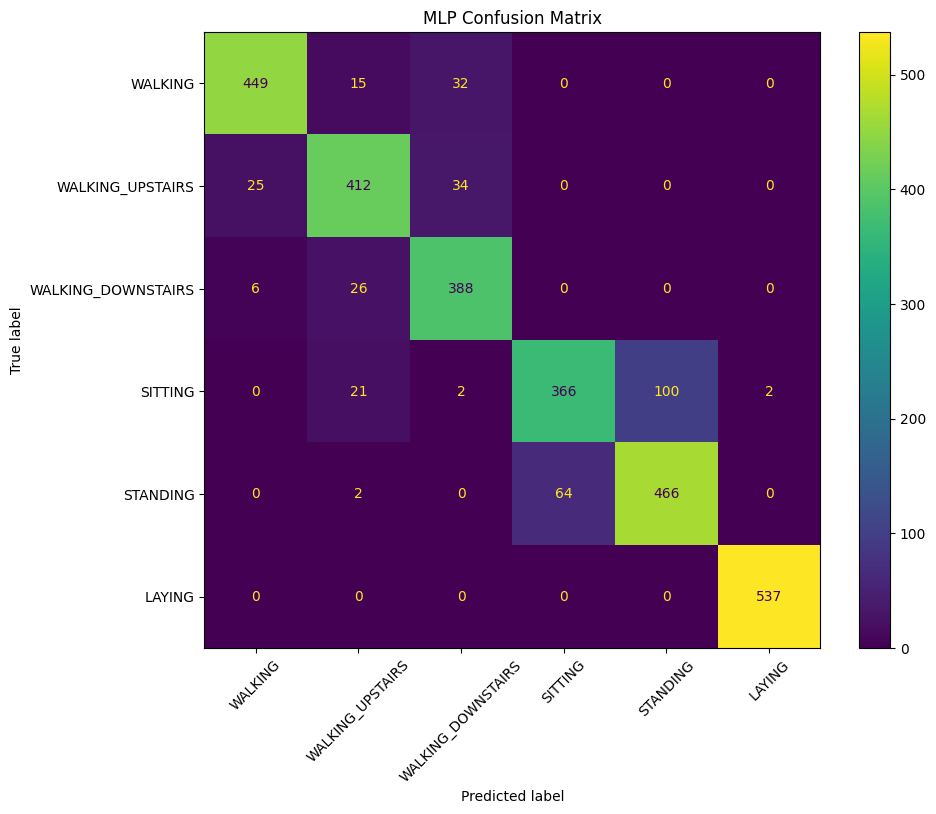

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=activity_names
)

fig, ax = plt.subplots(
    figsize=(10, 8)
)

disp.plot(
    ax=ax,
    xticks_rotation=45
)

plt.title("MLP Confusion Matrix")
plt.show()

In [31]:
total_params = model.count_params()

print(
    "Total parameters:",
    f"{total_params:,}"
)

Total parameters: 338,246


In [32]:
model.save(
    "/content/har_mlp.keras"
)

In [33]:
history_df = pd.DataFrame(
    history.history
)

history_df.to_csv(
    "/content/mlp_training_history.csv",
    index=False
)

In [34]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

results = {
    "Model": "MLP",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "Parameters": model.count_params(),
    "Training Time (s)": training_time
}

pd.DataFrame([results])

,Model,Accuracy,Precision,Recall,F1 Score,Parameters,Training Time (s)
0,MLP,0.888361,0.88902,0.888361,0.8877,338246,19.281944


In [35]:
pd.DataFrame([results]).to_csv(
    "/content/mlp_final_results.csv",
    index=False
)